In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# 1) CHARGEMENT ET FILTRAGE DES DONNÉES
# ============================================================

# Chargement du fichier
df_all = pd.read_csv("../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv", sep="\t")

# Sélection des 3 sites d'intérêt
target_sites = ["ds000030", "ds_cobre", "ds004302"]

# Sélection des diagnostics d'intérêt (CONTROL vs SCHZ)
# NOTE : Si vous voulez voir TOUS les diagnostics (ex: BIPOLAR, ADHD), commentez la ligne ci-dessous.
target_diag = ["CONTROL", "SCHZ"]

mask = (
    df_all["site_id"].isin(target_sites) & 
    df_all["diagnosis"].isin(target_diag)
)

df_viz = df_all.loc[mask].copy()

# Conversion correcte des types
df_viz["age"] = df_viz["age"].astype(float)

print("Nombre de sujets après filtrage :", df_viz.shape[0])
print(df_viz.groupby(["site_id", "diagnosis"]).size())

/tmp/ipykernel_899109/3849820011.py:6: DtypeWarning: Columns (93967) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv", sep="\t")


Nombre de sujets après filtrage : 389
site_id   diagnosis
ds000030  CONTROL      122
          SCHZ          50
ds004302  CONTROL       25
          SCHZ          46
ds_cobre  CONTROL       74
          SCHZ          72
dtype: int64


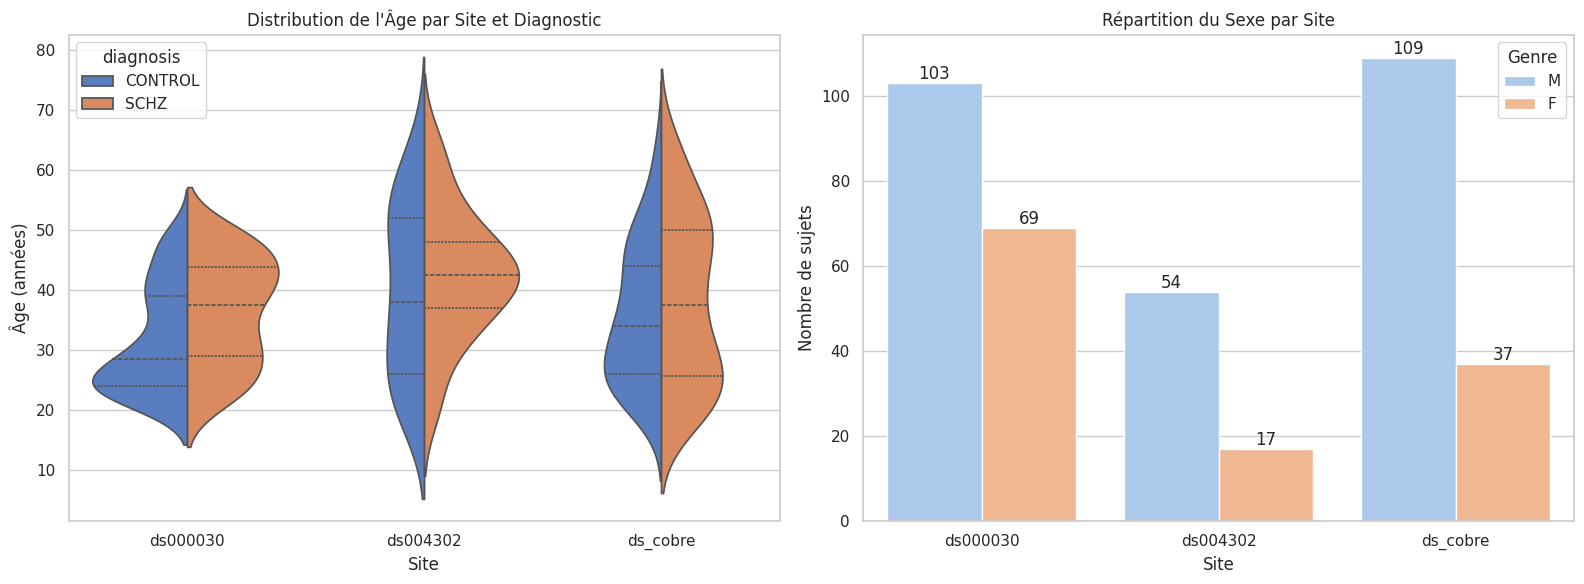

In [3]:
# ============================================================
# 2) VISUALISATION
# ============================================================

# Configuration du style graphique
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT A : Distribution de l'Âge (Boxplot ou Violinplot) ---
# Le "violinplot" montre la densité, le "split=True" compare les distributions côte à côte.
sns.violinplot(
    data=df_viz, 
    x="site_id", 
    y="age", 
    hue="diagnosis", 
    split=True, 
    inner="quart", 
    palette="muted",
    ax=axes[0]
)
axes[0].set_title("Distribution de l'Âge par Site et Diagnostic")
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Âge (années)")

# --- PLOT B : Distribution du Sexe (Countplot) ---
# Diagramme en barres pour compter M/F
sns.countplot(
    data=df_viz, 
    x="site_id", 
    hue="gender", 
    palette="pastel",
    ax=axes[1]
)

# Ajout des valeurs au-dessus des barres pour lisibilité
for container in axes[1].containers:
    axes[1].bar_label(container)

axes[1].set_title("Répartition du Sexe par Site")
axes[1].set_xlabel("Site")
axes[1].set_ylabel("Nombre de sujets")
axes[1].legend(title="Genre")

plt.tight_layout()
plt.show()

In [4]:
from scipy.stats import ttest_ind, chi2_contingency

print("\n" + "="*50)
print("ANALYSES STATISTIQUES PAR SITE")
print("="*50)

for site in ["ds000030", "ds_cobre", "ds004302"]:
    print(f"\n--- SITE : {site} ---")
    
    # Sous-ensembles
    df_site = df_viz[df_viz["site_id"] == site]
    group_ctrl = df_site[df_site["diagnosis"] == "CONTROL"]
    group_schz = df_site[df_site["diagnosis"] == "SCHZ"]
    
    # 1. TEST T SUR L'ÂGE
    t_stat, p_val_age = ttest_ind(group_ctrl["age"], group_schz["age"], nan_policy='omit')
    signif_age = "***" if p_val_age < 0.001 else "**" if p_val_age < 0.01 else "*" if p_val_age < 0.05 else "ns"
    
    print(f"[AGE]  Mean CTRL: {group_ctrl['age'].mean():.1f} | SCHZ: {group_schz['age'].mean():.1f}")
    print(f"       p-value : {p_val_age:.4f} ({signif_age})")
    
    # 2. TEST CHI-2 SUR LE SEXE
    # Table de contingence : [ [Hommes_Ctrl, Femmes_Ctrl], [Hommes_Schz, Femmes_Schz] ]
    # Note : gender 'M'/'F' -> on compte
    contingency = pd.crosstab(df_site['diagnosis'], df_site['gender'])
    if contingency.shape == (2, 2):
        chi2, p_val_sex, _, _ = chi2_contingency(contingency)
        signif_sex = "***" if p_val_sex < 0.001 else "**" if p_val_sex < 0.01 else "*" if p_val_sex < 0.05 else "ns"
        print(f"[SEXE] p-value : {p_val_sex:.4f} ({signif_sex})")
        print(f"       Répartition :\n{contingency}")
    else:
        print("[SEXE] Pas assez de données pour le Chi-2 (colonnes manquantes)")

print("\n" + "="*50)


ANALYSES STATISTIQUES PAR SITE

--- SITE : ds000030 ---
[AGE]  Mean CTRL: 31.6 | SCHZ: 36.5
       p-value : 0.0012 (**)
[SEXE] p-value : 0.0096 (**)
       Répartition :
gender      F   M
diagnosis        
CONTROL    57  65
SCHZ       12  38

--- SITE : ds_cobre ---
[AGE]  Mean CTRL: 35.8 | SCHZ: 38.2
       p-value : 0.2698 (ns)
[SEXE] p-value : 0.1539 (ns)
       Répartition :
gender      F   M
diagnosis        
CONTROL    23  51
SCHZ       14  58

--- SITE : ds004302 ---
[AGE]  Mean CTRL: 39.8 | SCHZ: 42.5
       p-value : 0.3644 (ns)
[SEXE] p-value : 0.7647 (ns)
       Répartition :
gender      F   M
diagnosis        
CONTROL     7  18
SCHZ       10  36

